## Ungraded Lab: MNIST Autoencoder

You will now work on an autoencoder that works on the [MNIST dataset](https://www.tensorflow.org/datasets/catalog/mnist). This will encode the inputs to lower resolution images. The decoder should then be able to generate the original input from this compressed representation.

In [1]:
!pip install tensorflow_datasets%pip install tensorflow-datasets

ERROR: Invalid requirement: 'tensorflow_datasets%pip'
You should consider upgrading via the 'C:\Users\ponnu\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
%pip install tensorflow-datasets

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\ponnu\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [3]:
%pip install --upgrade requests

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\ponnu\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [4]:
%pip install importlib_resources

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\ponnu\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


## Imports

In [5]:
try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
  
import tensorflow as tf
import tensorflow_datasets as tfds

import numpy as np
import matplotlib.pyplot as plt

## Prepare the Dataset

You will load the MNIST data from TFDS into train and test sets. Let's first define a preprocessing function for normalizing and flattening the images. Since we'll be training an autoencoder, this will return `image, image` because the input will also be the target or label while training.

##### map() function is used to apply a transformation to every element in the dataset.


In [6]:
def map_image(image, label):
  '''Normalizes and flattens the image. Returns image as input and label.'''
  image = tf.cast(image, dtype=tf.float32)
  image = image / 255.0
  image = tf.reshape(image, shape=(784,))

  return image, image

In [7]:
# Load the train and test sets from TFDS

BATCH_SIZE = 128
SHUFFLE_BUFFER_SIZE = 1024

train_dataset = tfds.load('mnist', as_supervised=True, split="train")
train_dataset = train_dataset.map(map_image)
train_dataset = train_dataset.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE).repeat()

test_dataset = tfds.load('mnist', as_supervised=True, split="test")
test_dataset = test_dataset.map(map_image)
test_dataset = test_dataset.batch(BATCH_SIZE).repeat()

## Build the Model

You will now build a simple autoencoder to ingest the data. Like before, the encoder will compress the input and reconstructs it in the decoder output.

[![auto.png](https://i.postimg.cc/c4nvrC5h/auto.png)](https://postimg.cc/kB7JHJCR)

In [8]:
import tensorflow as tf

def simple_autoencoder(inputs):
    encoder_output = tf.keras.layers.Dense(32, activation='relu')(inputs)
    decoder_output = tf.keras.layers.Dense(784, activation='sigmoid')(encoder_output)
    
    return encoder_output, decoder_output

In [9]:
# set the input shape
inputs = tf.keras.layers.Input(shape=(784,))

# get the encoder and decoder output
# (Make sure you already ran the cell defining the simple_autoencoder function!)
encoder_output, decoder_output = simple_autoencoder(inputs)

# setup the encoder to visualize its output later
encoder_model = tf.keras.Model(inputs=inputs, outputs=encoder_output)

# setup the autoencoder
autoencoder_model = tf.keras.Model(inputs=inputs, outputs=decoder_output)

In [10]:
autoencoder_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │          25,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 784)                 │          25,872 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)

## Compile the Model

You will setup the model for training. You can use binary crossentropy to measure the loss between pixel values that range from 0 (black) to 1 (white).

In [11]:
autoencoder_model.compile(
    optimizer=tf.keras.optimizers.Adam(), 
    loss='binary_crossentropy',metrics=['accuracy'])

## Train the Model

In [ ]:
train_steps = 60000 // BATCH_SIZE
simple_auto_history = autoencoder_model.fit(train_dataset, steps_per_epoch=train_steps, epochs=10)

Epoch 1/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.0125 - loss: 0.2290
Epoch 2/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.0108 - loss: 0.1413
Epoch 3/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.0098 - loss: 0.1192
Epoch 4/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.0105 - loss: 0.1078
Epoch 5/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.0107 - loss: 0.1012
Epoch 6/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.0105 - loss: 0.0977
Epoch 7/10
 69/468 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0106 - loss: 0.0970

## Display sample results

You can now visualize the results. The utility functions below will help in plotting the encoded and decoded values.

In [13]:
def display_one_row(disp_images, offset, shape=(28, 28)):
  '''Display sample outputs in one row.'''
  for idx, test_image in enumerate(disp_images):
    plt.subplot(3, 10, offset + idx + 1)
    plt.xticks([])
    plt.yticks([])
    test_image = np.reshape(test_image, shape)
    plt.imshow(test_image, cmap='gray')


def display_results(disp_input_images, disp_encoded, disp_predicted, enc_shape=(8,4)):
  '''Displays the input, encoded, and decoded output values.'''
  plt.figure(figsize=(15, 5))
  display_one_row(disp_input_images, 0, shape=(28,28,))
  display_one_row(disp_encoded, 10, shape=enc_shape)
  display_one_row(disp_predicted, 20, shape=(28,28,))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step


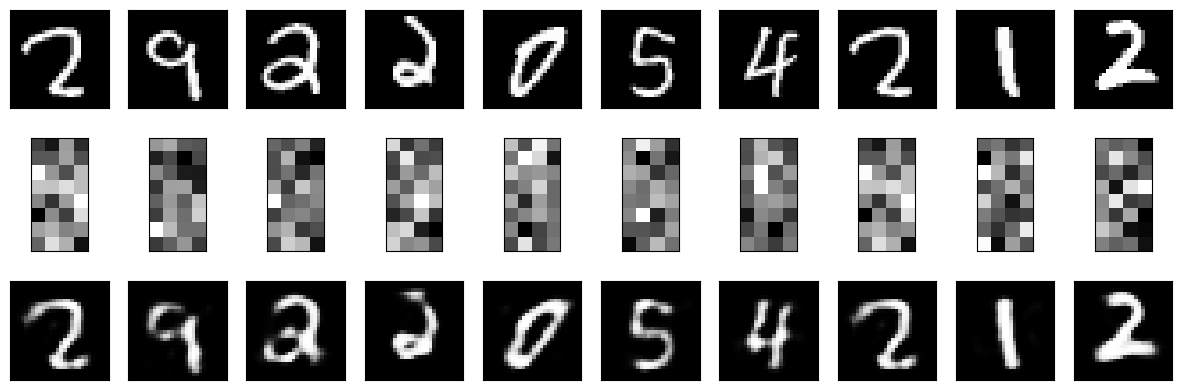

In [14]:
# take 1 batch of the dataset
test_dataset = test_dataset.take(1)

# take the input images and put them in a list
output_samples = []
for input_image, image in tfds.as_numpy(test_dataset):
      output_samples = input_image

# pick 10 random numbers to be used as indices to the list above
idxs = np.random.choice(BATCH_SIZE, size=10)

# get the encoder output
encoded_predicted = encoder_model.predict(test_dataset)

# get a prediction for the test batch
simple_predicted = autoencoder_model.predict(test_dataset)

# display the 10 samples, encodings and decoded values!
display_results(output_samples[idxs], encoded_predicted[idxs], simple_predicted[idxs])

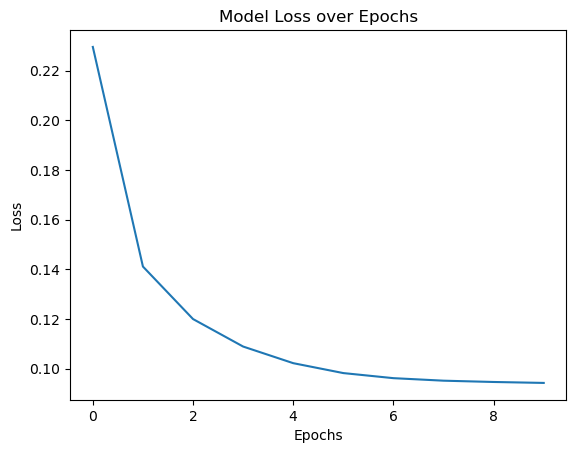

In [15]:
import matplotlib.pyplot as plt

# Plotting the training loss over epochs
plt.plot(simple_auto_history.history['loss'])
plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

[![Deep.png](https://i.postimg.cc/rp63MntX/Deep.png)](https://postimg.cc/JsqPQQqP)

In [25]:
import tensorflow as tf

def deep_autoencoder(inputs):
    encoder_output = tf.keras.layers.Dense(units=128, activation='relu')(inputs)
    encoder_output = tf.keras.layers.Dense(units=64, activation='relu')(encoder_output)
    encoder_output = tf.keras.layers.Dense(units=32, activation='relu')(encoder_output)

    decoder_output = tf.keras.layers.Dense(units=64, activation='relu')(encoder_output)
    decoder_output = tf.keras.layers.Dense(units=128, activation='relu')(decoder_output)
    decoder_output = tf.keras.layers.Dense(units=784, activation='sigmoid')(decoder_output)
    return encoder_output, decoder_output

    deep_encoder_output, deep_autoencoder_output = deep_autoencoder(inputs)

deep_encoder_model = tf.keras.Model(inputs=inputs, outputs=encoder_output)

deep_autoencoder_model = tf.keras.Model(inputs=inputs, outputs=decoder_output)

    

In [24]:
deep_autoencoder_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)